Phase 1 – Dataset Understanding

Step 1: Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/netflix_titles.csv")

In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,content_age,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,1,90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,0,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,0,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,0,2.0


### Column Description

Column: type  
Meaning: Movie or TV Show  
Business Use: Helps Netflix understand content strategy  

Column: country  
Meaning: Country where content is produced  
Business Use: Helps identify top content-producing regions  

Column: release_year  
Meaning: Year content was released  
Business Use: Helps analyze content trends  

Column: date_added  
Meaning: Date when content was added  
Business Use: Helps track Netflix growth  

Column: rating  
Meaning: Audience category  
Business Use: Helps understand target audience  

Step 2: Basic Structure

In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Total rows

Total columns

Data types

Column classification (Numerical / Categorical / Datetime / Text)

Column Meaning & Business Relevance

| Column Name  | What It Represents                               | Business Importance                      | Decision-Making Relevance                                   |
| ------------ | ------------------------------------------------ | ---------------------------------------- | ----------------------------------------------------------- |
| show_id      | Unique identifier for each title                 | Helps track records uniquely             | Useful for database management and indexing                 |
| type         | Indicates whether content is a Movie or TV Show  | Determines content distribution strategy | Helps decide investment allocation between formats          |
| title        | Name of the content                              | Used for identification and branding     | Useful for catalog management                               |
| director     | Director of the content                          | Reflects creative leadership             | Helps analyze popular creators                              |
| cast         | Actors involved                                  | Indicates star power                     | Can influence audience engagement strategy                  |
| country      | Country of production                            | Shows geographic production distribution | Helps identify dominant markets and expansion opportunities |
| date_added   | Date content was added to Netflix                | Tracks platform growth over time         | Helps analyze expansion phases                              |
| release_year | Year content was originally released             | Measures content freshness               | Determines focus on modern vs classic content               |
| rating       | Audience suitability classification              | Indicates target demographic             | Guides audience segmentation strategy                       |
| duration     | Length in minutes (movies) or seasons (TV shows) | Reflects engagement depth                | Helps evaluate viewer retention potential                   |
| listed_in    | Genre classification                             | Identifies content categories            | Guides genre investment decisions                           |
| description  | Short summary of the content                     | Provides content context                 | Can support future NLP or recommendation systems            |


🔷PHASE 2 – Data Quality Assessment

2.1 Missing Value Analysis

In [5]:
df.isnull().sum()
(df.isnull().sum()/len(df))*100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


* Which columns have missing values

* Percentage

* Your decision (remove / replace / keep)

* Justification

2.2 Duplicate Analysis

In [6]:
df.duplicated().sum()

np.int64(0)

If duplicates:

In [7]:
df.drop_duplicates(inplace=True)

🔹 2.3 Data Type Correction

### Data Cleaning Justification

Missing Values:
- The 'country' column had missing values, so it was filled with 'Unknown' to avoid losing data.
- Rows with missing 'date_added' were removed because date information is important for time-based analysis.

Duplicates:
- Duplicate rows were checked and removed to ensure data accuracy and avoid repeated analysis.

Data Type Conversion:
- The 'date_added' column was converted into datetime format to enable time-based analysis like year and month extraction.

In [16]:
# 1. Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 2. Remove rows where 'date_added' could not be converted
df = df.dropna(subset=['date_added'])

# 3. Create 'added_year' column
df['added_year'] = df['date_added'].dt.year

# 4. Calculate 'content_age'
df['content_age'] = df['added_year'] - df['release_year']

# 5. Extract numeric value from 'duration'
df['duration_int'] = df['duration'].str.extract(r'(\d+)')

# 6. Convert extracted duration to numeric
df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

# 7. Check results
print(df[['date_added','added_year','release_year','content_age','duration','duration_int']].head())

  date_added  added_year  release_year  content_age   duration  duration_int
0 2021-09-25        2021          2020            1     90 min          90.0
1 2021-09-24        2021          2021            0  2 Seasons           2.0
2 2021-09-24        2021          2021            0   1 Season           1.0
3 2021-09-24        2021          2021            0   1 Season           1.0
4 2021-09-24        2021          2021            0  2 Seasons           2.0


In [17]:
# Extract year and month from date_added
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month

# Calculate content age
df['content_age'] = df['added_year'] - df['release_year']

# Convert duration to numeric
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_403/3853255533.py:9: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)


🔷 PHASE 4 — UNIVARIATE ANALYSIS

1.TYPE (Movies vs TV Shows)

/tmp/ipykernel_403/1535780744.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


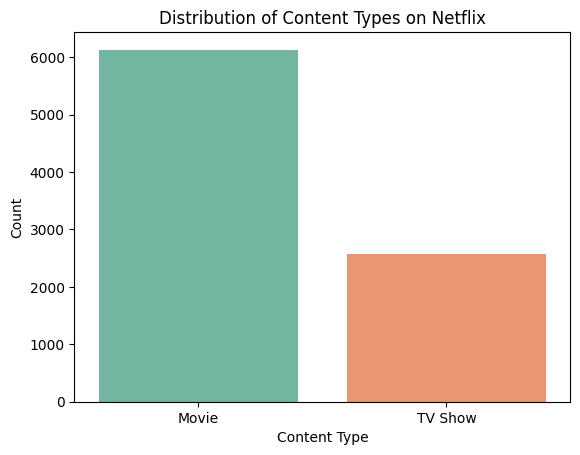

In [27]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title("Distribution of Content Types on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

Observation:
Movies are higher than TV Shows.

Interpretation:
Netflix produces more movies.

Business Insight:
Movies are easier to produce and reach a wider audience.

2:RATING DISTRIBUTION

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=df)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)

Observation:
TV-MA has the highest number of titles.

Interpretation:
Most content is targeted towards mature audiences.

Business Insight:
Netflix focuses more on adult viewers for engagement and retention.

3. RELEASE YEAR DISTRIBUTION

Text(0, 0.5, 'Count')

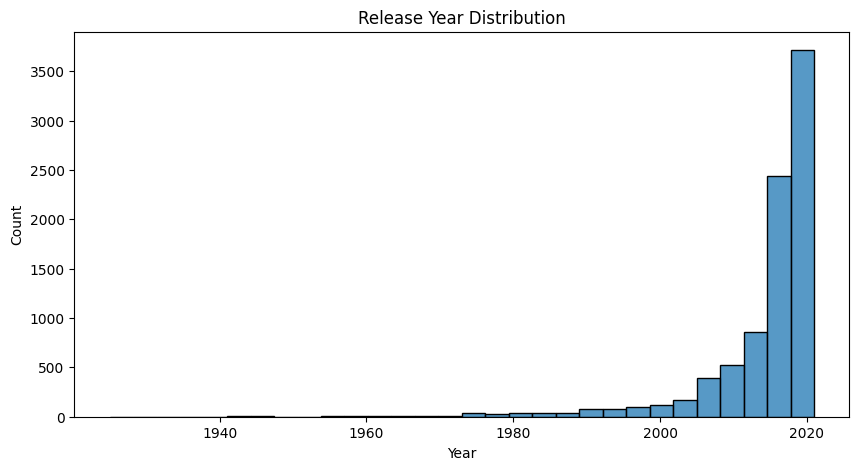

In [29]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.ylabel("Count")

Observation:
Most content is released after 2000.

Interpretation:
Netflix contains more recent content.

Business Insight:
Modern content attracts more viewers.

4. CONTENT ADDED PER YEAR

Text(0, 0.5, 'Number of Titles')

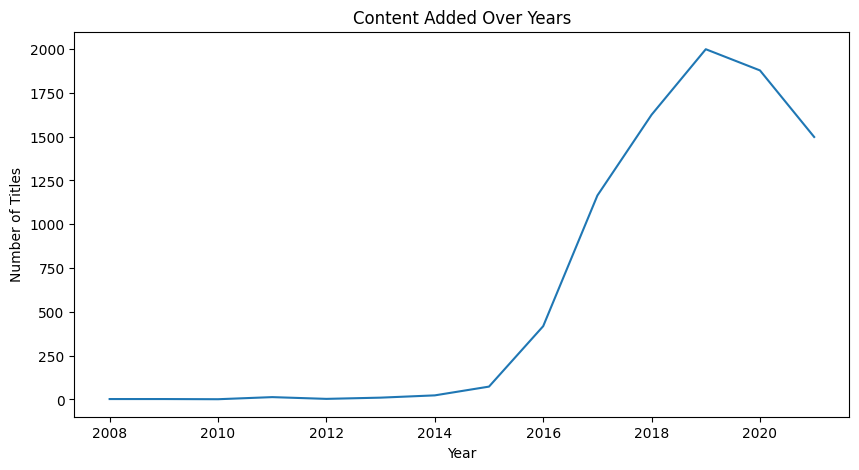

In [30]:
df['added_year'].value_counts().sort_index().plot(kind='line', figsize=(10,5))
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

Observation:
Content increased significantly after 2015.

Interpretation:
Netflix expanded rapidly in recent years.

Business Insight:
Aggressive content strategy increased platform growth.

5. COUNTRY DISTRIBUTION (TOP 10)

Text(0, 0.5, 'Country')

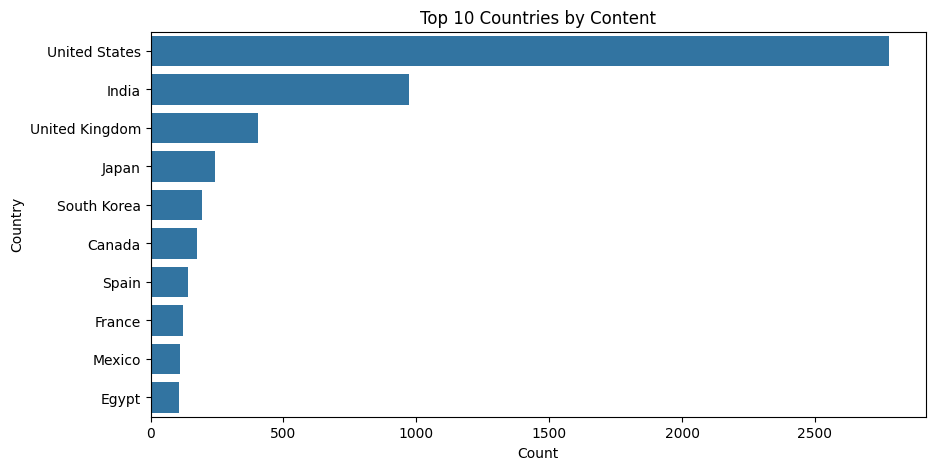

In [31]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Content")
plt.xlabel("Count")
plt.ylabel("Country")

Observation:
USA produces the highest content.

Interpretation:
USA dominates Netflix production.

Business Insight:
Netflix relies heavily on American content.

6. GENRE DISTRIBUTION (TOP 10)

Text(0, 0.5, 'Genre')

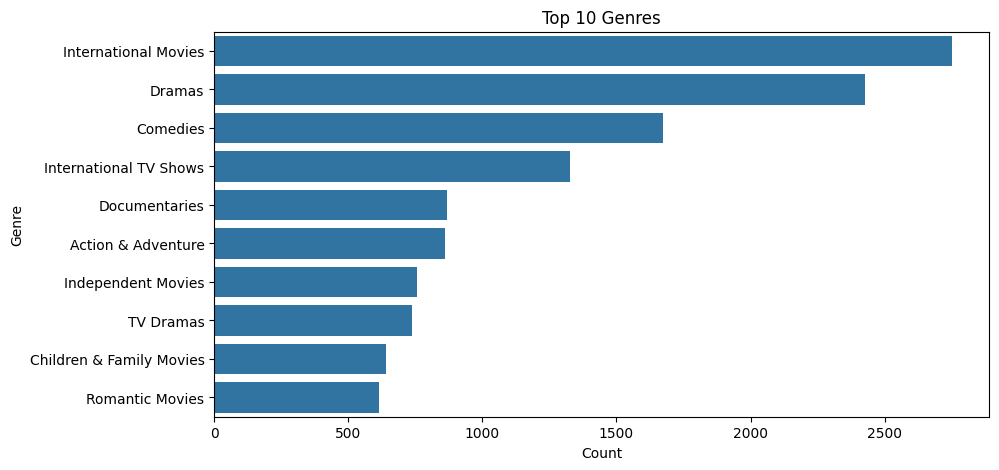

In [32]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")

Observation:
Drama and Comedy are the most common genres.

Interpretation:
Audience prefers emotional and entertaining content.

Business Insight:
Netflix focuses on popular genres to maximize engagement.

🔷 PHASE 5 — BIVARIATE ANALYSIS

Example: Type vs Rating

Text(0.5, 1.0, 'Type vs Rating')

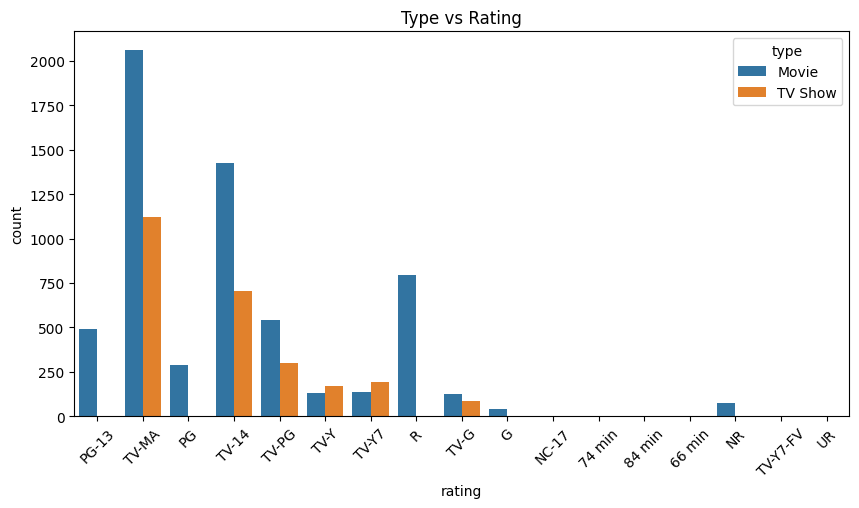

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', hue='type', data=df)
plt.xticks(rotation=45)
plt.title("Type vs Rating")

Observation:
TV-MA has the highest number of titles.

Interpretation:
Most content is targeted towards mature audiences.

Business Insight:
Netflix focuses more on adult viewers for engagement and retention.

2. COUNTRY vs TYPE

Text(0.5, 1.0, 'Country vs Content Type')

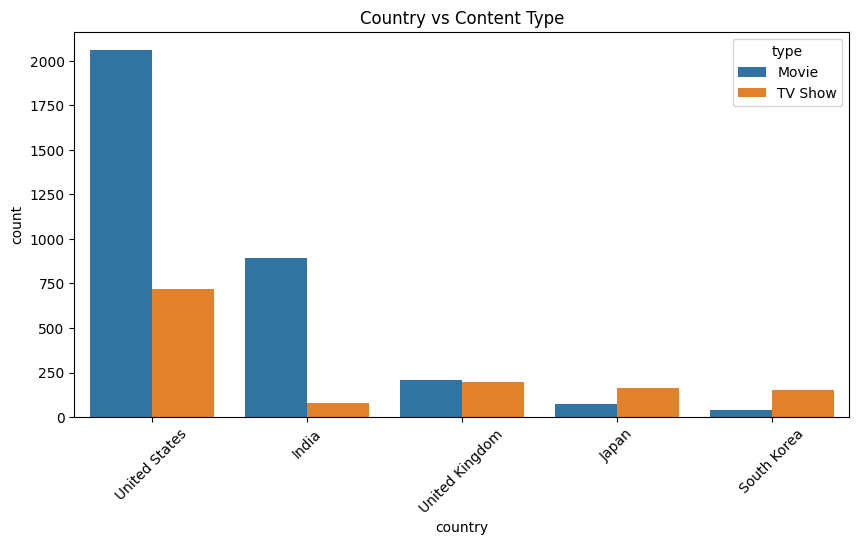

In [34]:
top_countries = df['country'].value_counts().head(5).index

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['country'].isin(top_countries)], x='country', hue='type')
plt.xticks(rotation=45)
plt.title("Country vs Content Type")

Observation:
USA has more movies than TV shows.

Interpretation:
Movies dominate in top countries.

Business Insight:
Netflix focuses on movie production globally.

3. RELEASE YEAR vs TYPE

Text(0, 0.5, 'Count')

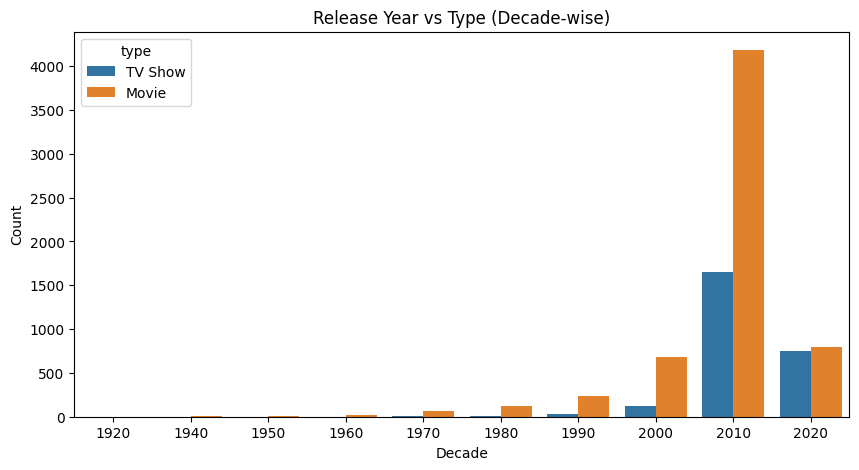

In [41]:
# Create decade column
df['decade'] = (df['release_year']//10)*10

plt.figure(figsize=(10,5))
sns.countplot(x='decade', hue='type', data=df)
plt.title("Release Year vs Type (Decade-wise)")
plt.xlabel("Decade")
plt.ylabel("Count")

Observation:
Most content is from recent decades.

Interpretation:
Netflix focuses on modern content.

Business Insight:
Recent content attracts more viewers and increases engagement.

4. ADDED YEAR vs NUMBER OF TITLES

Text(0, 0.5, 'Number of Titles')

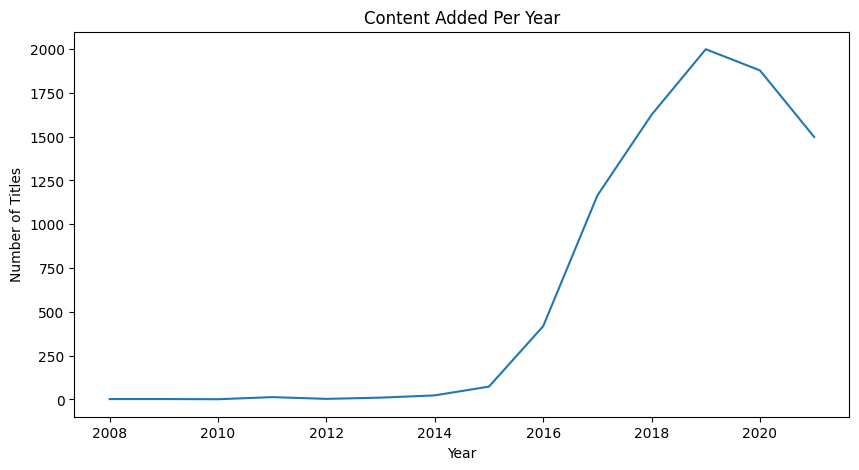

In [39]:
df['added_year'].value_counts().sort_index().plot(kind='line', figsize=(10,5))
plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

Observation:
Content added to Netflix increases significantly after 2015.

Interpretation:
Netflix expanded its content library rapidly in recent years.

Business Insight:
Netflix adopted an aggressive growth strategy by adding more content to attract and retain users.

5. GENRE vs RATING

In [ ]:
genre_df = df.copy()
genre_df['genre'] = genre_df['listed_in'].str.split(', ').str[0]

plt.figure(figsize=(10,5))
sns.countplot(data=genre_df, x='genre', hue='rating')
plt.xticks(rotation=45)
plt.title("Genre vs Rating")

Observation:
Different genres have different rating distributions.

Interpretation:
Genre influences target audience.

Business Insight:
Netflix aligns genre with audience preference.

6. DURATION vs RATING

Text(0.5, 1.0, 'Duration vs Rating')

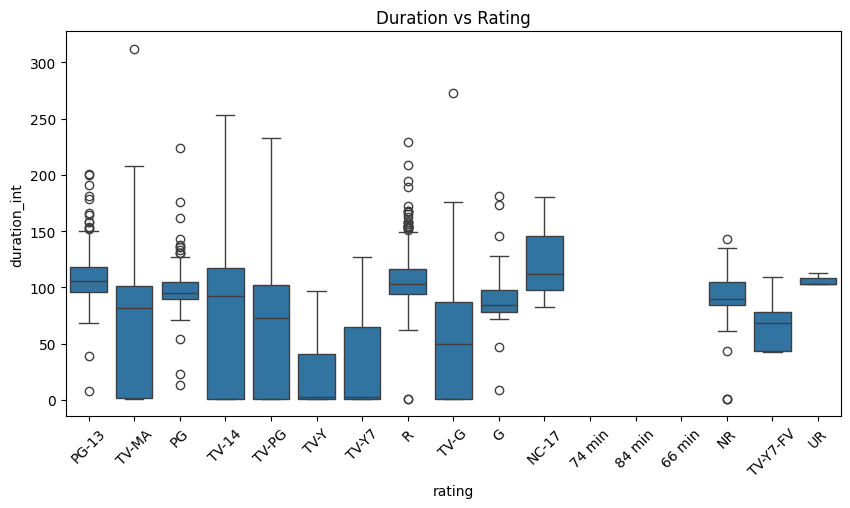

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x='rating', y='duration_int', data=df)
plt.xticks(rotation=45)
plt.title("Duration vs Rating")

Observation:
Duration varies across ratings.

Interpretation:
Longer content is often targeted at specific audiences.

Business Insight:
Content length is optimized based on audience category.

🔷 PHASE 6 — MULTIVARIATE

### Correlation Heatmap (Multivariate Analysis)

This heatmap shows the relationship between numerical features such as release year, content age, and duration.

Use heatmap

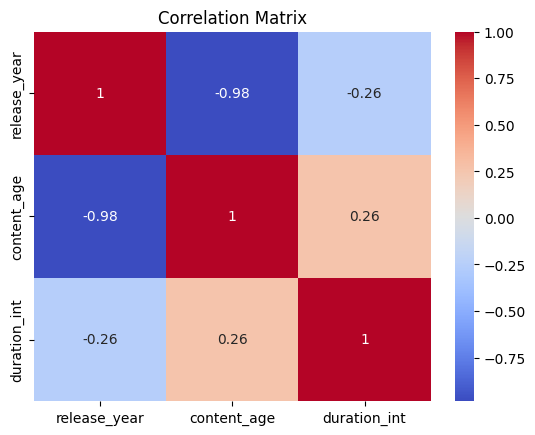

In [43]:
sns.heatmap(df[['release_year','content_age','duration_int']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Observation:
Correlation between variables is low.

Interpretation:
There is no strong relationship between the features.

Business Insight:
Netflix content strategy depends on multiple independent factors rather than a single variable.

2. COUNTRY vs GENRE vs TYPE

Text(0.5, 1.0, 'Country vs Genre (Top 5)')

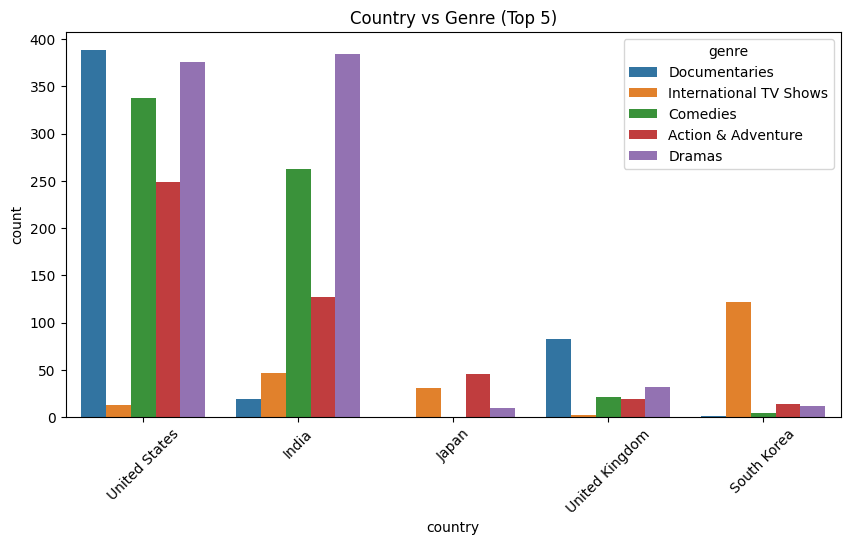

In [46]:
multi_df = df.copy()
multi_df['genre'] = multi_df['listed_in'].str.split(', ').str[0]

# Top 5 countries
top_countries = multi_df['country'].value_counts().head(5).index

# Top 5 genres
top_genres = multi_df['genre'].value_counts().head(5).index

filtered_df = multi_df[
    (multi_df['country'].isin(top_countries)) &
    (multi_df['genre'].isin(top_genres))
]

plt.figure(figsize=(10,5))
sns.countplot(data=filtered_df, x='country', hue='genre')
plt.xticks(rotation=45)
plt.title("Country vs Genre (Top 5)")

Observation:
Top countries produce different genres.

Interpretation:
Content varies based on region.

Business Insight:
Netflix customizes content based on country preferences.

3. YEAR vs GENRE TREND

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '2008'),
  Text(1, 0, '2009'),
  Text(2, 0, '2011'),
  Text(3, 0, '2012'),
  Text(4, 0, '2014'),
  Text(5, 0, '2015'),
  Text(6, 0, '2016'),
  Text(7, 0, '2017'),
  Text(8, 0, '2018'),
  Text(9, 0, '2019'),
  Text(10, 0, '2020'),
  Text(11, 0, '2021')])

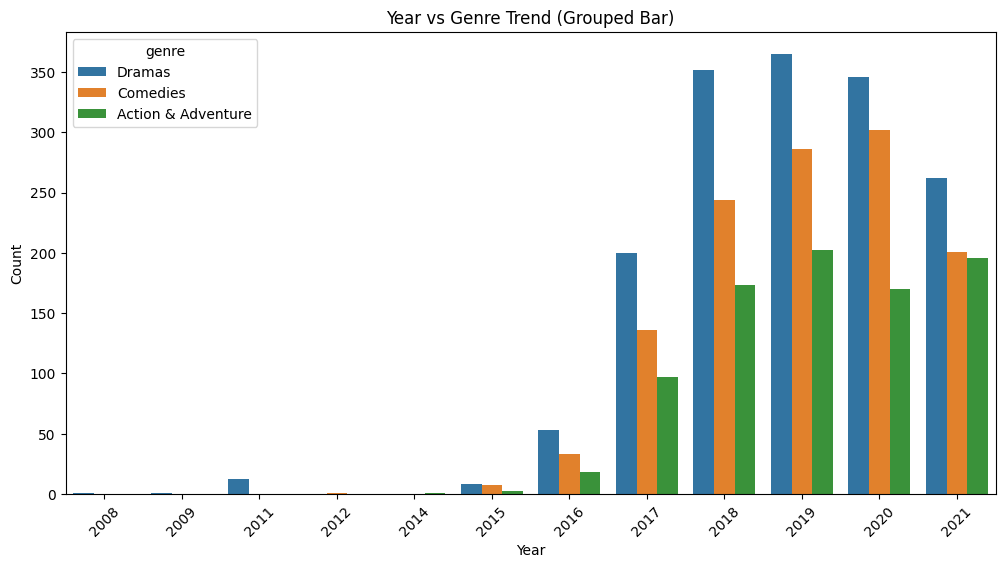

In [50]:
# Prepare data
multi_df = df.copy()
multi_df['genre'] = multi_df['listed_in'].str.split(', ').str[0]

# Top 3 genres (keep small to avoid mess)
top_genres = multi_df['genre'].value_counts().head(3).index
filtered_df = multi_df[multi_df['genre'].isin(top_genres)]

# Group data
grouped = filtered_df.groupby(['added_year','genre']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=grouped, x='added_year', y='count', hue='genre')

plt.title("Year vs Genre Trend (Grouped Bar)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)

Observation:
Top genres show different trends across years.

Interpretation:
Some genres increase more than others over time.

Business Insight:
Netflix focuses on growing genres based on audience demand.

4. RATING vs COUNTRY

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2008'),
  Text(1, 0, '2009'),
  Text(2, 0, '2010'),
  Text(3, 0, '2011'),
  Text(4, 0, '2012'),
  Text(5, 0, '2013'),
  Text(6, 0, '2014'),
  Text(7, 0, '2015'),
  Text(8, 0, '2016'),
  Text(9, 0, '2017'),
  Text(10, 0, '2018'),
  Text(11, 0, '2019'),
  Text(12, 0, '2020'),
  Text(13, 0, '2021')])

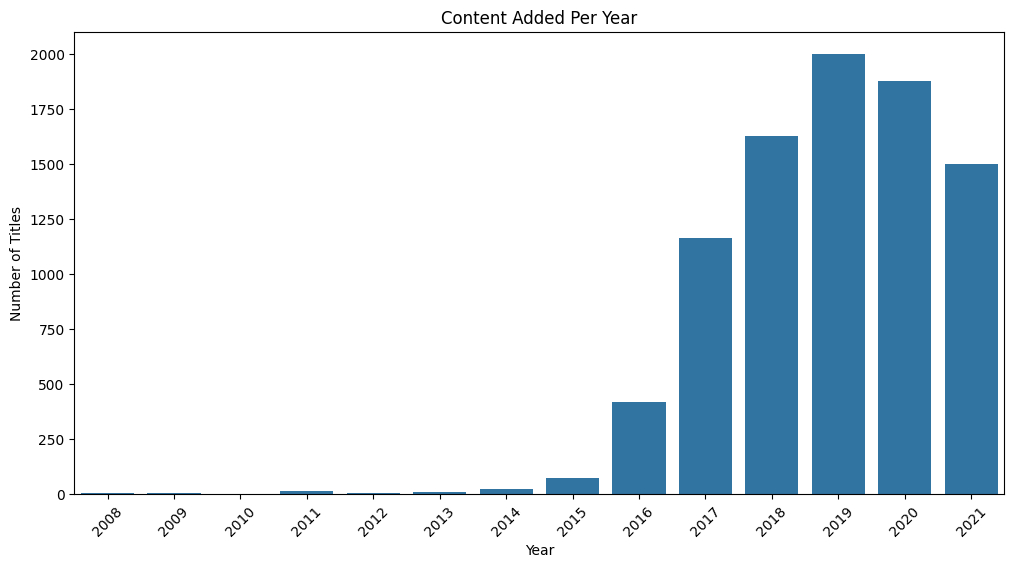

In [52]:
year_counts = df['added_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=year_counts.index, y=year_counts.values)

plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

Observation:
Content added increased significantly after 2015.

Interpretation:
Netflix expanded rapidly in recent years.

Business Insight:
Netflix adopted an aggressive growth strategy by adding more content.

🔷 PHASE 7 — BUSINESS INSIGHTS

### Business Insights

1. Which type dominates Netflix?

      Movies dominate Netflix. The number of movies is higher than TV shows, showing that Netflix focuses more on movie content.

2. Which country produces most content?

      The United States produces the highest content on Netflix, indicating its strong presence in global entertainment.

3. Which genres are most common?

      Drama and Comedy are the most common genres, showing audience preference for emotional and entertaining content.

4. Which year had maximum additions?

     The highest number of titles were added around 2018–2019, showing rapid growth during that period.

5. Is Netflix focusing more on recent content?

     Yes, most content is recent, indicating Netflix prioritizes new and trending content.

6. What rating category dominates?

     TV-MA is the most common rating, meaning Netflix mainly targets adult audiences.

7. What is the growth pattern after 2015?

     There is a significant increase in content after 2015, showing aggressive expansion.

8. Any unusual trends observed?

     Older content is less frequent, and Netflix focuses more on modern and popular genres.

Phase 8 – Visualization Quality Validation

The following visualization standards were applied throughout the project:

✔ Proper Figure Size
All charts were created using controlled figure dimensions to ensure readability and clarity.

✔ Meaningful Titles
Each visualization includes a descriptive and analytical title that clearly communicates the purpose of the chart.

✔ Axis Labeling
All axes are labeled appropriately to ensure interpretability.

✔ No Overlapping Labels
Rotations and spacing adjustments were applied where necessary to avoid clutter.

✔ Intentional Color Palette
Custom color palettes (e.g., Set2, coolwarm) were used instead of default styling to enhance readability.

✔ Heatmap Annotations
Correlation heatmaps include numerical annotations to improve interpretability.

✔ Readability Focus
Charts were structured to prioritize insight communication over decorative elements.

